## **Word2Vec (Skip-Gram)**
<div>
    <b>Abdh. Mohammadi</b><br>
    <a href="mailto:abdhmohammdi@alumni.um.ac.ir">📧 abdhmohammadi@alumni.um.ac.ir</a><br>
    <a href="mailto:abdhmohammdy@gmail.com">📧 abdhmohammady@gmail.com</a><br>
    <a href="https://abdhmohammadi.pages.dev"> 🌐 https://abdhmohammadi.pages.dev</a><br>
    <a href="https://github.com/abdhmohammadi"> Github</a>
    <a href="https://linkedin.com/in/abdhmohammadi"> LinkedIn</a> 
    <a href="https://t.me/abdhmohammadi"> Telegram</a><br>

    September 2025
</div>    

(under development ...)

***It is suggested that you read my CBOW notebook first.***

Word2Vec is a family of algorithms introduced by _Mikolov et al._ in 2013 to learn dense vector representations of words from large text corpora[1]. these vectors are called `embeddings`. These embeddings capture semantic relationships, such as similarity. There are two main architectures: _Continuous Bag-of-Words (CBOW)_ and _Skip-Gram_. In this notebook I'll focus on `Skip-gram`, which is efficient for infrequent words and predicts surrounding context words given a target(center) word. Skip-gram treats each context-target pair as a separate prediction task and `aims to maximize the probability of the context words given the target word`. It's a shallow neural network with no hidden non-linearities beyond the embeddings, trained via backpropagation.



### Common Applications

* **Word similarity / semantic search:** Find synonyms, analogies
* **Text classification / sentiment analysis**
* **Named Entity Recognition (NER)**
* **Machine translation / multilingual embeddings**
* **Recommendation systems** (product or content embeddings)
* **Clustering / topic modeling** using vector similarities

### From scratch implementation

Below is a complete, self-contained Python implementation of Skip-Gram using NumPy (no other Machne Learning libraries). It uses full softmax for simplicity, suitable for small corpora/vocabs. For large datasets, you'd need optimizations like `negative sampling`. Throughout this notebook, the following corpus is used to test the code. It need to define some helper functions like softmax. After the topic is complete, the all functions will be merged into the _SkipGram_ class.

In [4]:
# Simple corpus
import numpy as np

corpus = """    
Mary Vance walked down the Valley with her head held high. She had on a new blue velvet cap with a scarlet rosette in it, a coat of navy blue
cloth and a little squirrel-fur muff. She was very conscious of her new clothes and very well pleased with herself. Her hair was elaborately
crimped, her face was quite plump, her cheeks rosy, her white eyes shining. She did not look much like the forlorn and ragged waif the
Merediths had found in the old Taylor barn. Una tried not to feel envious. Here was Mary with a new velvet cap, but she and Faith had to
wear their shabby old gray tams again this winter. Nobody ever thought of getting them new ones and they were afraid to ask their father for
them for fear that he might be short of money and then he would feel badly. Mary had told them once that ministers were always short of
money, and found it “awful hard” to make ends meet. Since then Faith and Una would have gone in rags rather than ask their father for
anything if they could help it. They did not worry a great deal over their shabbiness; but it was rather trying to see Mary Vance coming out
in such style and putting on such airs about it, too. The new squirrel muff was really the last straw. Neither Faith nor Una had ever had a
muff, counting themselves lucky if they could compass mittens without holes in them. Aunt Martha could not see to darn holes and though Una
tried to, she made sad cobbling. Somehow, they could not make their greeting of Mary very cordial. But Mary did not mind or notice that;
she was not overly sensitive. She vaulted lightly to a seat on the pine tree, and laid the offending muff on a bough. Una saw that it was lined
with shirred red satin and had red tassels. She looked down at her own rather purple, chapped, little hands and wondered if she would ever,
_ever_ be able to put them into a muff like that.
"""

# Helper functions

# returns context words for given context indices.
def get_context(self, context_idx):
        context = []
        for idx in context_idx:
            context.append(self.idx_to_word[idx])

        return 

# returns one-hot vector of given word index. 
def one_hot(self, idx): return np.eye(self.vocab_size)[idx]

# Simple tokenization for educational porpose.
def tokenize(corpus): return corpus.lower().replace('.','').split()  

### Step 1: Problem Setup and Notation
- **Corpus**: A sequence of words $w_1, w_2, \dots, w_T$, where $T$ is the total number of words in the _corpus_.
- **Vocabulary**: A set of unique words $V = \{v_1, v_2, \dots, v_{|V|}\}$, with size $|V|$.
- **Center and Context words**: For a `center word`$^1$ $w_t$, the `context words`$^2$ is a window of $c$ words on each side, e.g., $[w_{t-c}, \dots, w_{t-1}, w_{t+1}, \dots, w_{t+c}]$. The context size (window size) is $2c$.
- **One-Hot Encoding**: Each word $w$ is represented as a one-hot vector $\mathbf{x} \in \mathbb{R}^{|V|}$, where $x_i = 1$ if $i$ corresponds to $w$, else $0$.
- **Embeddings**: We learn two weight matrices:
  - Input embedding matrix $\mathbf{W}_{in} \in \mathbb{R}^{d \times |V|}$, where $d$ is the `embedding dimension`$^3$ (e.g., 100-300), this is a _hyperparameter_. The embedding for a word with one-hot $\mathbf{x}$ is $\mathbf{h} = \mathbf{W}_{in}.\mathbf{x} \in \mathbb{R}^d$. <br>If $x_i=1$ then $\mathbf{W}_{in}.\mathbf{x}$ selects the column $i$ of matrix $\mathbf{W}_{in}$. thus $\mathbf{h}$ is the vector on column $\mathbf{i}$.
  
  - Output embedding matrix $\mathbf{W}_{out} \in \mathbb{R}^{|V| \times d}$, used to compute scores for the output layer.
- **Objective**: Maximize the average log probability over the corpus:
  $$J = \frac{1}{T} \sum_{t=1}^T \sum_{\begin{matrix}j=-c\\j \neq 0 \end{matrix}}^c \log P(w_{t+j} | w_t)$$
  $P(w_{t+j} | w_t)$ calculates the probability that $w_{t+j}$ is in the context of $w_t$. this method predicts the probability of given word $w$ occurring in context of other words. Maximizing $J$ maximizes the probability over all words in the corpus.

Here, Skip-Gram defination is initalized.

In [5]:
from collections import Counter

class SkipGram:
    def __init__(self, corpus, vocab_size=None, embedding_dim=100, window_size=2, learning_rate=0.025, epochs=5, min_count=5):
        
        self.corpus = tokenize(corpus)        # Simple tokenization for educational porpose.
        self.embedding_dim = embedding_dim    # Size of embeddings
        self.window_size = window_size        # used to slide window over center words
        self.learning_rate = learning_rate    # learning rate
        self.epochs = epochs                  # training epochs
        self.min_count = min_count            # Filter words by limited repeatation
        
        self.build_vocab(vocab_size) 
        self.initialize_weights()

        print(f'    Input embedding: {self.W.shape}')
        print(f'   Output embedding: {self.W_out.shape}')
        print(f'        Corpus size: {self.vocab_size + self.filtered_words}')
        print(f'    Vocabulary size: {self.vocab_size}')
        print(f'Embedding dimention: {self.embedding_dim}')
        print(f'     Filtered words: {self.filtered_words}')
        print(f'             Epochs: {epochs}')
    
    def build_vocab(self, vocab_size=None):
        # Count word frequencies
        word_counts = Counter(self.corpus)
        # Filter words by min_count
        self.vocab = [word for word, count in word_counts.most_common(vocab_size) if count >= self.min_count]
        self.vocab_size = len(self.vocab)
        self.filtered_words = word_counts.total() - self.vocab_size 
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}

    def initialize_weights(self):
        '''
            Inintalize default input and output weights
        '''
        # Input embeddings: d x |V|
        self.W = np.random.uniform(low=-0.5 / self.embedding_dim, high= 0.5 / self.embedding_dim,size= (self.embedding_dim, self.vocab_size))
        # Output embeddings: |V| x d
        self.W_out = np.random.uniform(low=-0.5 / self.embedding_dim,high= 0.5 / self.embedding_dim,size= (self.vocab_size, self.embedding_dim))

    # Generates training pairs ([context word indices], center word index)
    def generate_training_data(self):
        training_data = []
        for i in range(len(self.corpus)):
            word = self.corpus[i]
            # this eccures for filtered words(count < self.min_count is filtered in build_vocab)
            if word not in self.word_to_idx: continue

            # get index of selected word 
            target_idx = self.word_to_idx[word]
            context = []
            # generates 'context words'  
            for j in range(-self.window_size, self.window_size + 1):
                
                # J == 0 is equivalent to the center word
                if j == 0: continue

                if 0 <= i + j < len(self.corpus):
                    ctx_word = self.corpus[i + j]
                    if ctx_word in self.word_to_idx:
                        # append index to the 'context words' list
                        context.append(self.word_to_idx[ctx_word])
            # if context words is not empty ...
            if context: training_data.append((context, target_idx))
        # Each element contains a ([context word indices], center word index)
        return training_data  

### Code Explanation:
This step sets up the data structure and parameters, corresponding to defining the corpus, vocabulary, and embeddings in the mathematical formulation.
- **Initialization:** The `__init__` method sets hyperparameters (embedding dimension $d$, window size $c$, learning rate $\eta$, etc.) and preprocesses the corpus.
- **Vocabulary Building:** `build_vocab` counts word frequencies, filters out rare words (below `min_count`), and creates mappings between words and indices.
- **Weight Initialization:** `initialize_weights` creates the input embedding matrix $\mathbf{W}_{in}$ (shape $d \times |V|$) and output matrix $\mathbf{W}_{out}$ (shape $ |V| \times d $), initialized randomly with small values to avoid saturation.
- **One-Hot Encoding:** `one_hot` generates a _one-hot_ vector for a word index, used for the center word in training.


In the below, an object of `SkipGram class` has created to test the model. 

In [6]:
model = SkipGram(corpus, embedding_dim=10, window_size=2, min_count=1)

    Input embedding: (10, 194)
   Output embedding: (194, 10)
        Corpus size: 355
    Vocabulary size: 194
Embedding dimention: 10
     Filtered words: 161
             Epochs: 5


### Step 2: Forward Pass
In the Word2Vec model, the `forward pass` computes how likely a word is to appear in a given context, serving as the prediction step of the model. For Skip-gram, it estimates the probability of the surrounding context words given the center word $P(w_{t+j} | w_t)$. Mathematically, this is implemented through a softmax function that defines a conditional probability distribution over the vocabulary, where the similarity between word embeddings (inner products of input and output vectors) determines the likelihood of prediction. Thus, the forward pass has a clear `probabilistic interpretation`: it is equivalent to modeling conditional word probabilities in a language model.

In theory, Word2Vec defines the probability distribution, In Skip-Gram: $P(w_{t+j} \mid w_t)
$ using a softmax over the vocabulary. But in practice, directly computing this probability is _very expensive_ because the denominator of softmax requires summing over all words in the vocabulary (which can be millions). So instead of explicitly computing the probability, Word2Vec does the forward pass step: it projects the center word into embedding, and then multiplies by the output weight matrix to get scores (logits). These scores are then used in an approximation method (e.g., **negative sampling** or **hierarchical softmax**) to update the embeddings without computing the full probability distribution. In short, theoretically Word2Vec models the probability distribution of words. but practically computes the forward pass (vector operations) and approximates the probability using tricks like negative sampling.

**Forward Pass Network**: 
To calculate the loss function, we first compute the logit values, obtained by multiplying the output weight matrix $W_{out}$ with the hidden vector $\mathbf{h}$. This hidden vector is the embedding of the center word, which is selected from the input embedding matrix $W_{in}$. Initially, the values of both $W_{in}$ and $W_{out}$ are randomly initialized, typically using a `uniform distribution`. In the forward pass, we use these embeddings to form $\mathbf{h}$, calculate the logits through $W_{out}.h$, and then apply the loss function (such as cross-entropy) to optimize the model parameters.

The network has three layers: input (center), hidden (embedding), and output (softmax).

1. **Input Layer**: For the center word $w_t$, get its one-hot vector $\mathbf{x_t}$ and $\mathbf{W_{in}.x_t}$ selects the embedding vector of word $w_t$. So, $\mathbf{h}$ is the embedding vector of the center word.

2. **Hidden Layer**: The hidden layer $\mathbf{h = W_{in}.x_t} \in \mathbb{R}^d$ is the embedding of the target word (this does not need to compute average like CBOW). It projects the center word into the embedding space.

3. **Output Layer**: Compute unnormalized scores (logits) for input word $w_t$ by $\mathbf{u} = \mathbf{W}_{out} \mathbf{h} \in \mathbb{R}^{|V|}$ Then, apply softmax to get probabilities $P(w_{t+j} | w_t ) =y_{t+j}= \frac{e^{u_{t+j}}}{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}}$
   where $t+j$ is the index of a context word. this is equvalent to $y_{t+j}= softmax(u_{t+j})$

In [7]:
import numpy as np
# SoftMax function: f(x) = e^x/(sum(e^xi))
def softmax(x):
    exp_x = np.exp(x)
    # exp_x = np.exp(x- np.max(x)) this is numerically stable.
    return exp_x / exp_x.sum(axis=0)

x = [2,2.5,3.5]

s = softmax(x)
print(s)
print(sum(s))

[0.14024438 0.2312239  0.62853172]
1.0


In [8]:
def forward(self, center_word_idx):

    # Get hidden layer h for the center word
    h = self.W[:, center_word_idx]  # Shape: (embedding_dim,)
    
    # Compute logits u = W'^T h
    u = np.dot(self.W_out, h)  # Shape: (vocab_size,)
    
    # Compute softmax probabilities y
    # Subtract max for numerical stability
    y = softmax(u)

    return h, u, y

### Code Explanation:
This step implements the forward propagation, mapping the center word to a probability distribution over the vocabulary for each context word.
- **Hidden Layer:** The forward method takes the center word index (`target_idx`). It retrieves the corresponding column from $\mathbf{W}_{in}$ (embedding vector) to get $\mathbf{h}$.
- **Output Layer:** Computes `logits`$^4$ $\mathbf{u} = \mathbf{W}_{out} \mathbf{h}$ using matrix multiplication (NumPy’s @ operator).
- **Softmax:** The softmax method converts logits to probabilities, subtracting the maximum for numerical stability to prevent overflow in $e^{u_k}$.



### Review the some result

In [9]:
# build train data: Each element contains a ([context word indices], center word index)
data = model.generate_training_data()

# printing results for a random word in the data
idx = np.random.randint(0,len(data))

print(f'Center word: ({data[idx][1]}, {model.idx_to_word[data[idx][1]]})') # This prints 'center word'
print(f'The word indexed by {data[idx][1]} has context words indexed by {data[idx][0]}')

cwds = []
for idx in data[idx][0]: cwds.append((idx,model.idx_to_word[idx]))

print(f'Context words are: {cwds}')
h, u, y = forward(model,data[idx][1])

print(f'Size of h:{h.shape} (embedding dimention)')
print(f'Size of u:{u.shape} (vocabulary size)')
print(f'Size of y:{y.shape} (vocabulary size)')

print(f'Sum of the logits is {np.sum(u)}')
print(f'Sum of the softmax is {np.sum(y)}')

Center word: (46, he)
The word indexed by 46 has context words indexed by [0, 49, 28, 41]
Context words are: [(0, 'and'), (49, 'then'), (28, 'would'), (41, 'feel')]
Size of h:(10,) (embedding dimention)
Size of u:(194,) (vocabulary size)
Size of y:(194,) (vocabulary size)
Sum of the logits is -0.03216518527647556
Sum of the softmax is 1.0


### Step 3: Loss Function
The goal of the loss function in Skip-gram is to maximize the probability of predicting the true context words given the center word. In practice, the loss function (cross-entropy or negative log-likelihood) is minimized during training. Minimizing this loss is mathematically equivalent to maximizing the probability assigned to the correct word by the model. This encourages the model to learn word representations that make accurate predictions for the true words in their contexts. The predicted probability for a true context is $y_{t+j}$, and `we want this to be close to 1`. to obtain cross-entropy, we first compute $- \log P(w_{t+j} | \text{center})$ in the following:

$-\log \frac{e^{u_{t+j}}}{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}}=-(\log e^{u_{t+j}}-\log{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}})=-(u_{t+j}-\log{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}})=\boxed{-u_{t+j}+\log{\underset{k=1}{\overset{|V|}{\sum}}e^{u_k}}=E}$

> In practice, we minimize $E=-\log y_{t+j}$ instead of $y_{t+j}$ because $E$ penalizes low probabilities more strongly and is better suited for optimization. This helps the model learn to assign higher probability to the correct word. The main reason for using negative log likelihood (NLL) instead of just maximizing likelihood is not only to penalize low probabilities more strongly, but also because NLL provides a smooth, differentiable loss function suitable for gradient-based optimization. <br><br>NLL transforms the product of probabilities (maximum likelihood) into a sum via the logarithm, making optimization easier and numerically stable. It also ensures that the model is penalized more when it assigns low probability to the true word, which helps learning. So, both stronger penalization and optimization convenience are key reasons.

> Over a batch or the entire dataset, we average this loss where $\mathbf{u_{t+j}}$ is the **_logit_** of the given context word. The term $\mathbf{−u_{t+j}}$ penalizes the model if the logit of context word $\mathbf{u_{t+j}}$ is too small (we want it large). The $\mathbf{log\sum e^{u_k}}$ normalizes across all words in the vocabulary, ensuring a valid probability distribution. _So the loss is low when the context’s score $u_{t+j}$ is high relative to all other words’ scores_. This is exactly the negative log-likelihood of the correct word under the softmax distribution.

> In practice, for large $|V|$ e.g., 10,000+, computing the full softmax is expensive. The original Word2Vec uses approximations like _Negative Sampling_ or _Hierarchical Softmax_, but for this from-scratch implementation, we'll use full softmax for simplicity (assuming small vocabularies or toy examples).

In the following cell, we defined a simple loss function:

In [10]:
def compute_loss(y, context_word_indices):
    loss = 0
    for idx in context_word_indices:
        loss += -np.log(y[idx] + 1e-10)
    return loss


After forward pass can compute loss value of the model for each context word, It need to pass the center word to return `h`, `logits` and `softmax` values. Using `generate_training_data`, the `model` has created well-structured train data, Now I can access to each pair thruogh returned data. I access to center at index `0` of each element and also to a context word at index `1`.

In [11]:
# Generate training data
data = model.generate_training_data()

# Get one training example
context_indices,center_idx = data[idx]
print(f"Center word: {center_idx}, Context words: {context_indices}")

# Forward pass
h, u, y = forward(model, center_idx)

# Compute loss
loss = compute_loss(y, context_indices)
print(f"Loss: {loss}")

# vectorized
#loss_vec = compute_loss_vectorized(u_matrix, context_indices)
#print(f"Vectorized loss: {loss_vec:.4f}")

Center word: 6, Context words: [67, 10, 12, 68]
Loss: 21.077217501517588


### Step 4: Backpropagation

In backpropagation, the goal is to update the input weight matrix $W_{in}$ and the output weight matrix $W_{out}$. These updates are performed using the `gradient descent`$^5$ method. After obtaining the logits in the forward pass, the function $f$ is the loss function $E$, which measures the difference between the predicted distribution and the true target word(s). Here $W_{in} \leftarrow W_{in} - \eta \frac{\partial E}{\partial W_{in}}$ and $W_{out} \leftarrow W_{out} - \eta \frac{\partial E}{\partial \_{out}}$.

It is also noted that the softmax error term, $\frac{\partial E}{\partial u_k} = y_k - t_k$ and output error is $\mathbf{e = y-t}$ where $\mathbf{t}$ is the one-hot target ($t_t = 1$, others 0), and $\mathbf{y}$ is the softmax output.

**Update $\mathbf{W}_{out}$:**
For each context word $w_{t+j}$ in the window, we predict it using the center embedding $\mathbf{h} = \mathbf{w}_t$.
Since $u_k = \mathbf{W}_{out,k} \cdot \mathbf{h}$, the gradient for the row of $\mathbf{W}_{out}$ corresponding to word $k$ is:

$$
\frac{\partial E}{\partial \mathbf{W}_{out,k}} = (y_k - t_k)\,\mathbf{h}^T
$$

In matrix form for one target word:

$$
\frac{\partial E}{\partial \mathbf{W}_{out}} = \mathbf{e}\,\mathbf{h}^T
$$

So, update rule is:

$$
\boxed{\mathbf{W}_{out} \leftarrow \mathbf{W}_{out} - \eta \,\mathbf{e}\,\mathbf{h}^T}
$$

This is repeated for **each context word** in the window.

**Update $\mathbf{W}_{in}$:**
The error backpropagates through the linear map $u = W_{out}h$:

$$
\frac{\partial E}{\partial \mathbf{h}} = \mathbf{W}_{out}^T \mathbf{e}
$$

Since $\mathbf{h}$ is just the center word embedding $\mathbf{w}_t$, the gradient applies **only to $\mathbf{w}_t$** (unlike CBOW where it was distributed to multiple context words):

$$
\frac{\partial E}{\partial \mathbf{w}_t} = \mathbf{W}_{out}^T \mathbf{e}
$$

So, update rule for the center word embedding:

$$
\boxed{\mathbf{w}_t \leftarrow \mathbf{w}_t - \eta \cdot \mathbf{W}_{out}^T \mathbf{e}}
$$

In [12]:

def backward(self, center_word_idx, context_word_idx, y, learning_rate=0.01):
    # Compute gradient w.r.t. u
    t = np.zeros(self.vocab_size)  # One-hot vector for context word
    t[context_word_idx] = 1
    e = y - t  # Shape: (vocab_size,)
    
    # Get hidden layer h
    h = self.W[:, center_word_idx]  # Shape: (embedding_dim,)
    
    # Compute gradient w.r.t. W' (outer product: h * (y - t)^T)
    grad_W_out = np.outer(e, h.T)  # Shape: (embedding_dim, vocab_size)
    
    # Compute gradient w.r.t. h
    grad_h = np.dot(e,self.W_out)  # Shape: (embedding_dim,)
    
    # Compute gradient w.r.t. W (only center_word_idx column is updated)
    grad_W = np.zeros_like(self.W)  # Shape: (embedding_dim, vocab_size)
    grad_W[:, center_word_idx] = grad_h
    

    self.W_out -= learning_rate * grad_W_out

    self.W -= learning_rate * grad_W
    
    return grad_W, grad_W_out

### Code Explanation:

This step computes and applies gradients to update the model parameters, aligning with the mathematical derivation.

* This function (extracted from the `train` loop for clarity) handles backpropagation.
* **Output Weights:** For each context word $w_{t+j}$, compute the error $ \mathbf{e} = \mathbf{y} - \mathbf{t} $, then update the corresponding output weights using the gradient $ \mathbf{e}\mathbf{h}^T $ (via `np.outer`).
* **Hidden Layer Error:** Backpropagate the error to the hidden layer embedding (the center word) using $ \frac{\partial E}{\partial \mathbf{h}} = {\mathbf{W}_{out}}^T \mathbf{e} $. This is done for each context word, and the gradients are accumulated.
* **Input Weights:** Since $h$ corresponds only to the center word embedding $\mathbf{w}_t$, the accumulated gradient updates the single column of $ \mathbf{W}_{in}$ corresponding to the center word index. Unlike CBOW, the gradient is **not divided among context embeddings** but aggregated for the center embedding.

    Input embedding: (10, 194)
   Output embedding: (194, 10)
        Corpus size: 355
    Vocabulary size: 194
Embedding dimention: 10
     Filtered words: 161
             Epochs: 10
This code tests loss of center word "103:getting".
Value of Loss for word "getting" after 1000 epochs is 5.151670953600091, 
in real usage this is applied over all words in the vocabulary.
The figure shows changes of 1000 epochs for center word "getting".
In next cell "train" function is implemented based on this code.


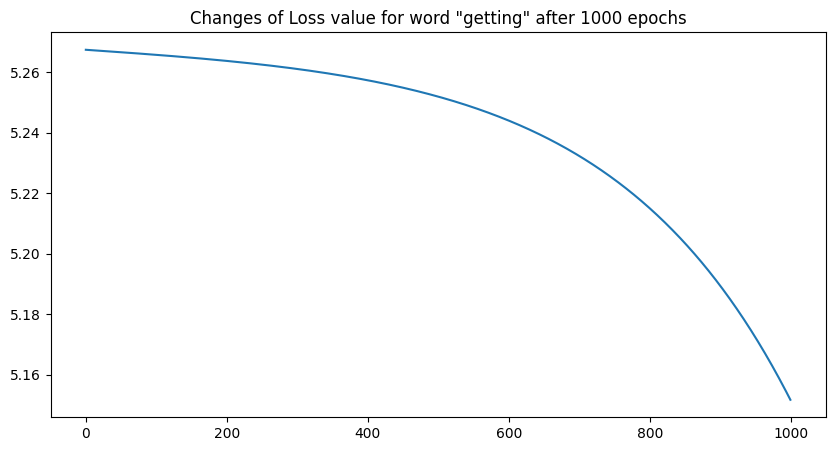

In [13]:
import matplotlib.pyplot as plt
import numpy as np
# Initialize Skip-Gram model
model = SkipGram(corpus, embedding_dim=10, window_size=2, epochs=10, min_count=1)

# Access training samples
data = model.generate_training_data()
# printing results for a random word in the data
idx = np.random.randint(0,len(data))

center_word = data[idx][1]         # input (center)
context_words = data[idx][0]       # output(s)

# Ensure context_words is a list
if isinstance(context_words, int): context_words = [context_words]

loss = []
epochs = 1000

for epoch in range(epochs):
  
  #for context_words, center_word in training_data:
    # Forward
    h, u, y = forward(model, center_word)
    # Compute loss over all context words
    e = compute_loss(y, context_words)
    e /= len(context_words)  # average per context word
    
    # Backward: update for each context word
    for o in context_words:
        backward(model, center_word, o, y, learning_rate=0.001)
    
    # loss of epoch
    loss.append(e)
    
    #break # just first item

    
#####################################################################################

print(f'This code tests loss of center word "{center_word}:{model.idx_to_word[center_word]}".')
print(f'Value of Loss for word "{model.idx_to_word[center_word]}" after {epochs} epochs is {e}, '
      f'\nin real usage this is applied over all words in the vocabulary.')
print(f'The figure shows changes of {epochs} epochs for center word "{model.idx_to_word[center_word]}".\n'
      'In next cell "train" function is implemented based on this code.')

plt.figure(figsize=(10,5))
plt.title(f'Changes of Loss value for word "{model.idx_to_word[center_word]}" after {epochs} epochs')
plt.plot(loss)
plt.show()


### Step 5: Training

* **Initialization**: Initialize the input embeddings $\mathbf{W}_{in}$ and output embeddings $\mathbf{W}_{out}$ randomly, e.g., uniform in $[-0.5/N, 0.5/N]$, to avoid saturation in activations.

* **Subsampling and Negatives**: For efficiency, subsample frequent words from the corpus and optionally use negative sampling. Negative words are sampled **proportional to their frequency raised to the 0.75 power**, similar to Word2Vec.

* **Training Loop**:

  1. For each center word in the corpus, consider its context words within the window.
  2. For each context word, compute the forward pass: center → context prediction.
  3. Compute the loss (negative log-likelihood) for all predicted context words.
  4. Backpropagate the error to update the center word embedding and the corresponding output embeddings.

* After training, the **input embeddings $\mathbf{W}_{in}$** are typically used as the final word vectors.

* This setup **learns embeddings** where words that appear in similar contexts have **close vectors** in the embedding space (measured via dot product similarity).

In [14]:

def train(self, print_epochs=False):
    
    training_data =  self.generate_training_data()
    print(f'       Running loop: {len(training_data)}x{self.epochs} = {len(training_data)*self.epochs}')
    print('Training ...')
    
    loss = []

    for epoch in range(self.epochs):
        epoch_loss = 0
        for context_words, center_word in training_data:
            # Forward
            h, u, y = forward(model, center_word)
    
            # Ensure context_words is a list
            #if isinstance(context_words, int): context_words = [context_words]

            # Compute average of loss over all context words
            e = compute_loss(y, context_words)/len(context_words)
            
            epoch_loss +=e
            
            # Backward: update for each context word
            for o in context_words:
                backward(model, center_word, o, y, learning_rate=0.001)
            
        # average loss of epoch
        loss.append(epoch_loss / len(training_data))

        if print_epochs: print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {epoch_loss / len(training_data):.4f}")

    print('Training ends.')
    
    return loss


### Code Explanation

This step ties everything together, iterating over the dataset and optimizing the embeddings using the computed gradients.

* **Data Generation:**
  `generate_training_data` creates training pairs `(center index, context index)` by sliding a window of size $2c$ over the corpus, skipping out-of-vocabulary words.

  * Each center word is paired with each of its context words individually.

* **Training Loop:**
  The `train` method iterates over epochs, processing each training example:

  1. Calls `forward` with the **center word** and its **list of context words** to get:

     * $\mathbf{h}$ → center embedding
     * $\mathbf{u_{list}}$ → logits for each context word
     * $\mathbf{y_{list}}$ → predicted probabilities for each context word

  2. Computes the loss for **all context predictions** (using `compute_loss`) and averages it per example.

  3. Calls `backward` to update:

     * $\mathbf{W}_{in}$ → center word embedding
     * $\mathbf{W}_{out}$ → rows corresponding to each predicted context word

  4. Reports the average loss per epoch.

* **Embedding Retrieval:**
  `get_embedding` extracts the learned embedding for a word from $\mathbf{W}_{in}$.

    Input embedding: (10, 194)
   Output embedding: (194, 10)
        Corpus size: 355
    Vocabulary size: 194
Embedding dimention: 10
     Filtered words: 161
             Epochs: 500
       Running loop: 355x500 = 177500
Training ...
Training ends.


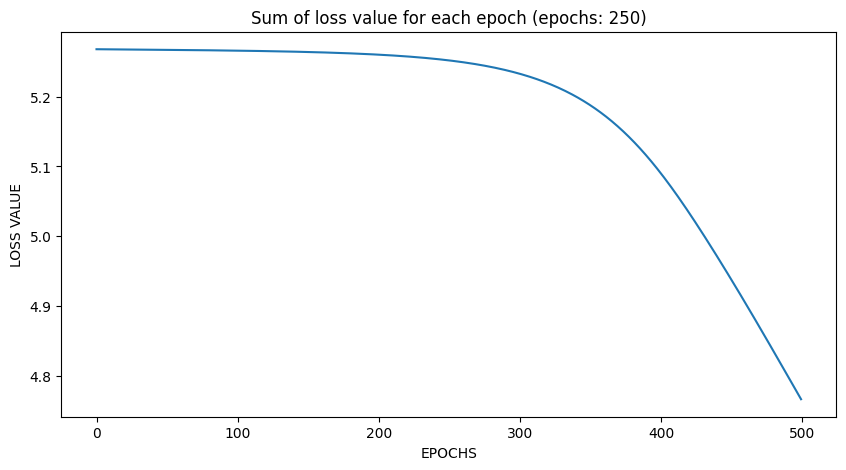

In [15]:
import matplotlib.pyplot as plt

# Initialize Skip-Gram model
model = SkipGram(corpus, embedding_dim=10, window_size=2, epochs=500, min_count=1)

# Train the model
loss = train(model, print_epochs=False)

# Plot the training loss
plt.figure(figsize=(10,5))
plt.xlabel('EPOCHS')
plt.ylabel('LOSS VALUE')
plt.title(f'Sum of loss value for each epoch (epochs: {250})')
plt.plot(loss)
plt.show()


### Mergeing the codes
Below is the complete code with the steps clearly separated, incorporating the isolated compute_loss and backward functions for clarity. It’s equivalent to the original but modularized to match the five steps.

In [16]:
import numpy as np
from collections import Counter

class SkipGram:
    def __init__(self, corpus, vocab_size=None, embedding_dim=100, window_size=2, learning_rate=0.025, epochs=5, min_count=5):
        
        self.corpus = tokenize(corpus)        # Simple tokenization for educational porpose.
        self.embedding_dim = embedding_dim    # Size of embeddings
        self.window_size = window_size        # used to slide window over center words
        self.learning_rate = learning_rate    # learning rate
        self.epochs = epochs                  # training epochs
        self.min_count = min_count            # Filter words by limited repeatation
        
        self.build_vocab(vocab_size) 
        self.initialize_weights()

        print(f'    Input embedding: {self.W.shape}')
        print(f'   Output embedding: {self.W_out.shape}')
        print(f'        Corpus size: {self.vocab_size + self.filtered_words}')
        print(f'    Vocabulary size: {self.vocab_size}')
        print(f'Embedding dimention: {self.embedding_dim}')
        print(f'     Filtered words: {self.filtered_words}')
        print(f'             Epochs: {epochs}')
    
    def build_vocab(self, vocab_size=None):
        # Count word frequencies
        word_counts = Counter(self.corpus)
        # Filter words by min_count
        self.vocab = [word for word, count in word_counts.most_common(vocab_size) if count >= self.min_count]
        self.vocab_size = len(self.vocab)
        self.filtered_words = word_counts.total() - self.vocab_size 
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}

    def initialize_weights(self):
        '''
            Inintalize default input and output weights
        '''
        # Input embeddings: d x |V|
        self.W = np.random.uniform(low=-0.5 / self.embedding_dim, high= 0.5 / self.embedding_dim,size= (self.embedding_dim, self.vocab_size))
        # Output embeddings: |V| x d
        self.W_out = np.random.uniform(low=-0.5 / self.embedding_dim,high= 0.5 / self.embedding_dim,size= (self.vocab_size, self.embedding_dim))

    # Generates training pairs ([context word indices], center word index)
    def generate_training_data(self):
        training_data = []
        for i in range(len(self.corpus)):
            word = self.corpus[i]
            # this eccures for filtered words(count < self.min_count is filtered in build_vocab)
            if word not in self.word_to_idx: continue

            # get index of selected word 
            target_idx = self.word_to_idx[word]
            context = []
            # generates 'context words'  
            for j in range(-self.window_size, self.window_size + 1):
                
                # J == 0 is equivalent to the center word
                if j == 0: continue

                if 0 <= i + j < len(self.corpus):
                    ctx_word = self.corpus[i + j]
                    if ctx_word in self.word_to_idx:
                        # append index to the 'context words' list
                        context.append(self.word_to_idx[ctx_word])
            # if context words is not empty ...
            if context: training_data.append((context, target_idx))
        # Each element contains a ([context word indices], center word index)
        return training_data  

    def forward(self, center_word_idx):

        # Get hidden layer h for the center word
        h = self.W[:, center_word_idx]  # Shape: (embedding_dim,)
        
        # Compute logits u = W'^T h
        u = np.dot(self.W_out, h)  # Shape: (vocab_size,)
        
        # Compute softmax probabilities y
        # Subtract max for numerical stability
        y = softmax(u)

        return h, u, y


    def compute_loss(y, context_word_indices):
        loss = 0
        for idx in context_word_indices:
            loss += -np.log(y[idx] + 1e-10)
        return loss
    

    def backward(self, center_word_idx, context_word_idx, y, learning_rate=0.01):
        # Compute gradient w.r.t. u
        t = np.zeros(self.vocab_size)  # One-hot vector for context word
        t[context_word_idx] = 1
        e = y - t  # Shape: (vocab_size,)
        
        # Get hidden layer h
        h = self.W[:, center_word_idx]  # Shape: (embedding_dim,)
        
        # Compute gradient w.r.t. W' (outer product: h * (y - t)^T)
        grad_W_out = np.outer(e, h.T)  # Shape: (embedding_dim, vocab_size)
        
        # Compute gradient w.r.t. h
        grad_h = np.dot(e,self.W_out)  # Shape: (embedding_dim,)
        
        # Compute gradient w.r.t. W (only center_word_idx column is updated)
        grad_W = np.zeros_like(self.W)  # Shape: (embedding_dim, vocab_size)
        grad_W[:, center_word_idx] = grad_h
        
        self.W_out -= learning_rate * grad_W_out

        self.W -= learning_rate * grad_W
        
        return grad_W, grad_W_out

    def train(self, verbose=True):
        
        training_data =  self.generate_training_data()
        print(f'       Running loop: {len(training_data)}x{self.epochs} = {len(training_data)*self.epochs}')
        print('Training ...')
        
        loss = []

        for epoch in range(self.epochs):
            epoch_loss = 0
            for context_words, center_word in training_data:
                # Forward
                h, u, y = forward(model, center_word)
        
                # Ensure context_words is a list
                #if isinstance(context_words, int): context_words = [context_words]

                # Compute average of loss over all context words
                e = compute_loss(y, context_words)/len(context_words)
                
                epoch_loss +=e
                
                # Backward: update for each context word
                for o in context_words:
                    backward(model, center_word, o, y, learning_rate=0.001)
                
            # average loss of epoch
            loss.append(epoch_loss / len(training_data))

            if verbose: print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {epoch_loss / len(training_data):.4f}")

        print('Training ends.')
        
        self.loss = loss

    def get_embedding(self, word):
        """
        Get embedding for a word
        """
        if word in self.word_to_idx:
            return self.W[:, self.word_to_idx[word]]
        else:
            return None

    def most_similar(self, word, top_n=5):
        """
        Find most similar words
        """
        if word not in self.word_to_idx:
            return []
        
        # Get query embedding
        query_embedding = self.get_embedding(word)
        
        # Calculate cosine similarities
        similarities = {}
        for idx, other_word in self.idx_to_word.items():
            if other_word != word:
                other_embedding = self.W[:, idx]
                cosine_sim = np.dot(query_embedding, other_embedding) / (
                    np.linalg.norm(query_embedding) * np.linalg.norm(other_embedding)
                )
                similarities[other_word] = cosine_sim
        
        # Return top N most similar words
        return sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    

### Test the Class

    Input embedding: (10, 194)
   Output embedding: (194, 10)
        Corpus size: 355
    Vocabulary size: 194
Embedding dimention: 10
     Filtered words: 161
             Epochs: 500
       Running loop: 355x500 = 177500
Training ...
Training ends.


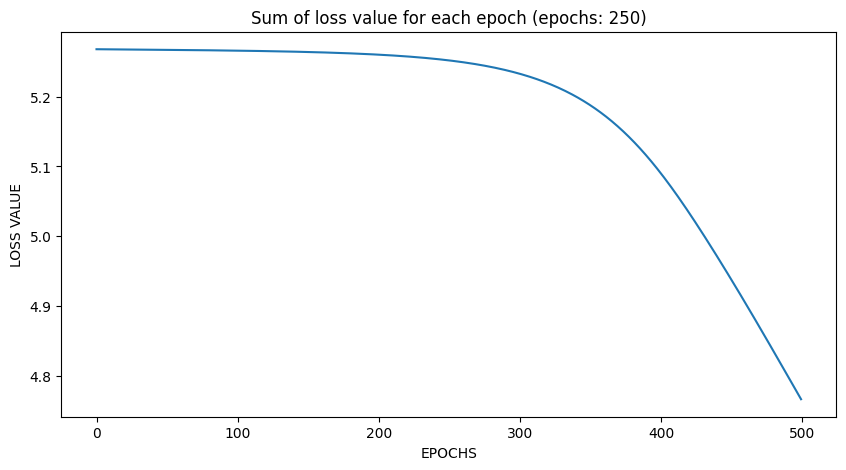

In [17]:
model = SkipGram(corpus, embedding_dim=10, window_size=2, epochs=500, min_count=1)

model.train(verbose=False)

loss_list = model.loss

# Plot the training loss
plt.figure(figsize=(10,5))
plt.xlabel('EPOCHS')
plt.ylabel('LOSS VALUE')
plt.title(f'Sum of loss value for each epoch (epochs: {250})')
plt.plot(loss)
plt.show()

### Import outer class

One copy of class SkipGram has been defined in the `./TextVectorization/py/`

We test it by importing to the notebook

    Input embedding: (10, 194)
   Output embedding: (194, 10)
        Corpus size: 355
    Vocabulary size: 194
Embedding dimention: 10
     Filtered words: 161
             Epochs: 500
       Running loop: 355x500 = 177500
Training ...
Training ends.


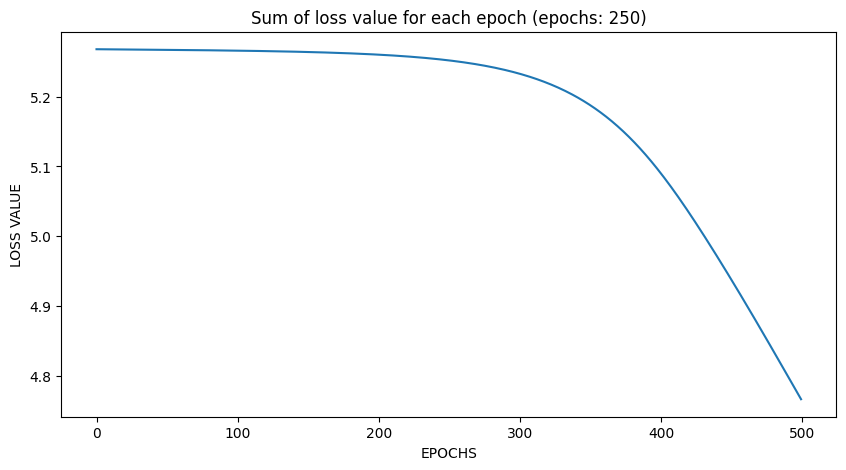

In [18]:
import sys
import os
sys.path.append(os.path.abspath("."))   # adds current folder (NLP) to path

from py import SkipGram as sk

model = sk.SkipGram(corpus, embedding_dim=10, window_size=2, epochs=500, min_count=1)

model.train(verbose=False)

loss_list = model.loss

# Plot the training loss
plt.figure(figsize=(10,5))
plt.xlabel('EPOCHS')
plt.ylabel('LOSS VALUE')
plt.title(f'Sum of loss value for each epoch (epochs: {250})')
plt.plot(loss)
plt.show()

This breakdown makes the implementation modular and directly traceable to the mathematical steps, aiding understanding. For large-scale use, consider adding negative sampling or hierarchical softmax to reduce computational cost, as noted in the original explanation. You can run this code with a small corpus as shown, and it will produce embeddings for each word in the vocabulary. the embedding vectors are available by **get_embedding(word)** for each word in the vocabulary.

---

## **Negative Sampling** (updating ...)
Negative Sampling is an `optimization technique` used in training models like Word2Vec (including CBOW and Skip-gram) to make the learning process more computationally efficient, especially for large vocabularies[1]. Below, We will explain negative sampling in the context of Skip-gram model, focusing on its purpose and mathematical foundation.


To update the Skip-gram implementation with negative sampling, we need to modify the `loss function` and `gradient computation` to make training more efficient. Negative sampling avoids computing the full softmax by approximating the loss using the target word and a small number of randomly sampled "negative" words. Below, we’ll explain the changes in the context of the mathematical background and provide the updated code, keeping the same five-step structure from the previous steps. The changes primarily affect `Step 3` (Loss Function) and `Step 4` (Backpropagation), with minor adjustments elsewhere to support negative sampling.

### Mathematical Background
In the original Skip-gram implementation, we used the full softmax loss, $E$, This requires computing $e^{u_k}$ for all words in the vocabulary $V$, which is computationally expensive for large vocabularies (e.g., $|V| > 10,000$). Negative Sampling approximates the loss by considering only the target word (positive example) and $K$ randomly sampled negative words (typically $K = 5-20 $). Negative words are sampled from a noise distribution, often the unigram distribution raised to the power of 0.75: $P(w) \propto \text{freq}(w)^{0.75}$ [2]. The loss becomes:
 $$E = -\log \sigma(u_{t+j}) - \overset{K}{\underset{k=1}{\sum}} \log \sigma(-u_k)$$

represents the `error` or `negative log-likelihood` that the model is trying to minimize. A lower value of $E$ indicates a better prediction by the model.
* **$u_{t+j}$** (logit) represents the dot product between the learned center vector (the input vector of the center word) and the output vector of the true context word $w_{t+j}$. In essence, it's a measure of the similarity or compatibility between the center and the context word.

* **$\sigma(x)$** is the `Sigmoid function`, defined as $\sigma(x) = \frac{1}{1 + e^{-x}}$. It squashes the input $x$ (in this case, $u_{t+j}$) into a probability-like value between `0` and `1`. The sigmoid function here represents the model's predicted probability that $w_{t+j}$ is a `positive (context) word` given the center.

* **$\log \sigma(u_{t+j})$**: This is the `log-probability` of the true context word. Since $\sigma(u_{t+j})$ is between `0` and `1`, $\log \sigma(u_{t+j})$ will be a `negative` number (e.g., $\log(0.9) \approx -0.105$).

* **$-\log \sigma(u_{t+j})$**: This is the `negative log-probability`. Because the model is trying to maximize $\sigma(u_{t+j})$ (i.e., maximize the predicted probability of the context word), minimizing the negative log-probability achieves this goal. If $\sigma(u_{t+j})$ is close to 1, $-\log \sigma(u_{t+j})$ is close to 0 (low loss).

* **$k=1$ to $K$**: represents the summation over $K$ `randomly` selected words that are `not` the context word $w_{t+j}$. These are the `negative samples`.


* **$u_k$**: This is the dot product between the learned center vector and the output vector of the $k^{th}$ `negative sample` $w_k$.

* **$\sigma(-u_k)$**: Since we want the model to predict that the negative sample $w_k$ is **not** the context word, we look at the probability $\sigma(-u_k)$.
    * Recall that $\sigma(-x) = 1 - \sigma(x)$. Therefore, $\sigma(-u_k)$ represents $1 - \sigma(u_k)$, which is the model's predicted probability that $w_k$ is a _`negative`_` (non-context) word` given the center.

* **$\log \sigma(-u_k)$** is the `log-probability` that the $k^{th}$ negative word is a `negative sample`. The model wants this probability to be high (close to 1).

* **$-\overset{K}{\underset{k=1}{\sum}} \log \sigma(-u_k)$** is the sum of the negative log-probabilities of all negative samples. By `minimizing` this term, the model is forced to `maximize` the log-probability of each $\sigma(-u_k)$, thereby pushing the probability that each random word is a negative sample `closer to 1`.

> Negative Sampling reduces the computational cost from $\mathcal{O}(|V|)$ to $\mathcal{O}(K + 1)$ per training example. and the gradients only update the weights for the target word and the $K$ negative words, not the entire $\mathbf{W}_{out}$.<br><br>In essence, the negative sampling loss function transforms the large, computationally expensive task of classifying the context word out of the entire vocabulary into a series of $K+1$ `independent binary classification tasks`:<br><br>1.  `One positive task`, Is the context word $w_{t+j}$ the correct word? (We want the prediction $\sigma(u_{t+j}) \approx 1$).<br>2.  `K negative tasks`, Are the randomly sampled words $w_k$ the correct word? (We want the predictions $\sigma(u_k) \approx 0$, which is achieved by maximizing $\sigma(-u_k)$ to $\approx 1$).<br><br>The overall goal is to find word vectors such that the dot product with the center vector is `large and positive` for the true context word ($u_{t+j} \to \infty$) and `large and negative` for all the sampled negative words ($u_k \to -\infty$).

**Gradient Updates**:
- For the context word $t+j$:$\frac{\partial E}{\partial u_{t+j}} = \sigma(u_{t+j}) - 1$

  Update $\mathbf{W}_{t+j} \leftarrow \mathbf{W}_{t+j} - \eta (\sigma(u_{t+j}) - 1) \mathbf{h}$.
- For a negative word $k$: $\frac{\partial E}{\partial u_k} = \sigma(u_k)$

  Update $\mathbf{W}_k \leftarrow \mathbf{W}_k - \eta \sigma(u_k) \mathbf{h}$.
- The error backpropagated to the hidden layer is: $\frac{\partial E}{\partial \mathbf{h}} = (\sigma(u_{t+j}) - 1) \mathbf{W}_{t+j} + \overset{K}{\underset{k=1}{\sum}} \sigma(u_k) \mathbf{W}_k$

- The input embeddings $\mathbf{W}_{in}$ are updated as before, using $\frac{\partial E}{\partial \mathbf{h}}$ for the center word.

**Sampling Negative Words**:
- We sample negatives from $P(w) \propto \text{freq}(w)^{0.75}$, which gives more weight to frequent words but less than their raw frequency, balancing informativeness.

### Updated Code with Negative Sampling
The code retains the five-step structure, with changes in **Step 3 (Loss Function)** and **Step 4 (Backpropagation)** to implement negative sampling. Additionally, we modify **Step 1 (Problem Setup)** to compute the unigram distribution for sampling negatives. The forward pass and training loop are adjusted slightly to accommodate the new loss and gradient updates.

In [ ]:
import numpy as np
from collections import Counter
import random

class SkipGram:
    # Step 1: Problem Setup (Updated for Negative Sampling)
    def __init__(self, corpus, vocab_size=None, embedding_dim=100, window_size=2, learning_rate=0.025, epochs=5, min_count=5, neg_samples=5):
        self.corpus = corpus.lower().split()
        self.embedding_dim = embedding_dim
        self.window_size = window_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.min_count = min_count
        self.neg_samples = neg_samples  # Number of negative samples
        self.build_vocab(vocab_size)
        self.initialize_weights()
        self.build_unigram_table()
    
    def build_vocab(self, vocab_size=None):
        word_counts = Counter(self.corpus)
        self.vocab = [word for word, count in word_counts.most_common(vocab_size) if count >= self.min_count]
        self.vocab_size = len(self.vocab)
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}
        # Store word frequencies for negative sampling
        self.word_freqs = np.array([word_counts[word] for word in self.vocab], dtype=float)
        self.word_freqs = self.word_freqs ** 0.75  # Unigram^0.75
        self.word_freqs /= self.word_freqs.sum()  # Normalize to probabilities
        print(f"Vocabulary size: {self.vocab_size}")
    
    def build_unigram_table(self):
        # Create a table for efficient negative sampling
        table_size = 1_000_000
        self.unigram_table = []
        for idx in range(self.vocab_size):
            count = int(self.word_freqs[idx] * table_size)
            self.unigram_table.extend([idx] * count)
    
    def initialize_weights(self):
        self.W = np.random.uniform(-0.5 / self.embedding_dim, 0.5 / self.embedding_dim, (self.embedding_dim, self.vocab_size))
        self.W_out = np.random.uniform(-0.5 / self.embedding_dim, 0.5 / self.embedding_dim, (self.vocab_size, self.embedding_dim))
    
    def one_hot(self, idx):
        return np.eye(self.vocab_size)[idx]
    
    # Step 2: Forward Pass (Adjusted for Negative Sampling)
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def forward(self, target_idx):
        h = self.W[:, target_idx]
        return h
    
    # Step 3: Loss Function (Negative Sampling)
    def compute_loss(self, h, context, neg_samples):
        # Positive sample
        u_pos = np.dot(self.W_out[context], h)
        loss = -np.log(self.sigmoid(u_pos))
        
        # Negative samples
        for neg_idx in neg_samples:
            u_neg = np.dot(self.W_out[neg_idx], h)
            loss -= np.log(self.sigmoid(-u_neg))
        
        return loss
    
    # Step 4: Backpropagation and Gradients (Negative Sampling)
    def backward(self, target_idx, context, h, neg_samples):
        # Gradient for positive sample
        u_pos = np.dot(self.W_out[context], h)
        grad_pos = self.sigmoid(u_pos) - 1
        dh = grad_pos * self.W_out[context]
        self.W_out[context] -= self.learning_rate * grad_pos * h
        
        # Gradients for negative samples
        for neg_idx in neg_samples:
            u_neg = np.dot(self.W_out[neg_idx], h)
            grad_neg = self.sigmoid(u_neg)
            dh += grad_neg * self.W_out[neg_idx]
            self.W_out[neg_idx] -= self.learning_rate * grad_neg * h
        
        # Update input embeddings
        self.W[:, target_idx] -= self.learning_rate * dh
    
    # Step 5: Training and Hyperparameters
    def generate_training_data(self):

        training_data = []
        for i in range(len(self.corpus)):
            word = self.corpus[i]
            if word not in self.word_to_idx:
                continue
            target_idx = self.word_to_idx[word]
            for j in range(-self.window_size, self.window_size + 1):
                if j == 0:
                    continue
                if 0 <= i + j < len(self.corpus):
                    ctx_word = self.corpus[i + j]
                    if ctx_word in self.word_to_idx:
                        training_data.append((target_idx, self.word_to_idx[ctx_word]))
        return training_data
    
    def sample_negatives(self, context):
        # Sample K negative words, excluding the context
        negatives = []
        while len(negatives) < self.neg_samples:
            idx = random.choice(self.unigram_table)
            
            if idx != context: negatives.append(idx)
        
        return negatives
    
    def train(self):
        training_data = self.generate_training_data()
        for epoch in range(self.epochs):
            total_loss = 0
            for target, context in training_data:
                h = self.forward(target)
                neg_samples = self.sample_negatives(context)
                E = self.compute_loss(h, context, neg_samples)
                total_loss += E
                self.backward(target, context, h, neg_samples)
            print(f"Epoch {epoch + 1}/{self.epochs}, Loss: {total_loss / len(training_data):.4f}")
    
    
    def get_embedding(self, word):
        if word in self.word_to_idx:
            return self.W[:, self.word_to_idx[word]]
        return None

In [ ]:
# Example usage
corpus = "We are about to study the idea of a computational process. Computational processes are abstract beings that inhabit computers. " \
"As they evolve, processes manipulate other abstract things called data. The evolution of a process is directed by a pattern of rules " \
"called a program. People create programs to direct processes. In effect, we conjure the spirits of the computer with our spells."
model = SkipGram(corpus, embedding_dim=10, window_size=2, epochs=10, min_count=1, neg_samples=5)
model.train()
print("Embedding for 'process':", model.get_embedding('process'))

Vocabulary size: 46
Epoch 1/10, Loss: 4.1585
Epoch 2/10, Loss: 4.1577
Epoch 3/10, Loss: 4.1565
Epoch 4/10, Loss: 4.1551
Epoch 5/10, Loss: 4.1509
Epoch 6/10, Loss: 4.1448
Epoch 7/10, Loss: 4.1316
Epoch 8/10, Loss: 4.1101
Epoch 9/10, Loss: 4.0714
Epoch 10/10, Loss: 3.9990
Embedding for 'process': [ 0.04961031  0.07507851 -0.00701664  0.12390568  0.01871773 -0.05124965
 -0.04462624  0.00891941  0.03838161  0.04374622]


In [ ]:
print(max(model.unigram_table))
print(sum(model.unigram_table))
print(len(model.unigram_table))

45
19003626
999986


### Summary of CBOW vs Skip-Gram Comparison

From an application perspective, **Continuous Bag-of-Words (CBOW)** and **Skip-gram**, the two main architectures of Word2Vec, differ in their approach to learning word embeddings and are suited to different use cases based on their strengths. Below is a concise explanation of their differences in terms of application, focusing on their practical implications:

### **1. CBOW (Continuous Bag-of-Words)**
- **How it works**: CBOW predicts a target (center) word based on the surrounding context words within a fixed window. It takes the average of context word embeddings to predict the center word.
- **Application View**:
  - **Strengths**:
    - **Faster training**: CBOW is computationally more efficient because it averages context word embeddings, requiring fewer computations per training example compared to Skip-gram.
    - **Better for frequent words**: It performs well on frequent words as it aggregates context information, smoothing out noise and capturing general semantic patterns.
    - **Suited for smaller datasets**: CBOW tends to generalize better when the training corpus is limited, as it leverages multiple context words to predict one target word.
  - **Use Cases**:
    - **General NLP tasks**: CBOW is often preferred for tasks like text classification, sentiment analysis, or named entity recognition (NER) where embeddings for frequent words need to be robust and training speed is a priority.
    - **Applications with resource constraints**: When computational resources are limited or faster training is needed (e.g., on smaller hardware or in production pipelines), CBOW is a better choice.
    - **Broad semantic relationships**: CBOW is effective for applications requiring embeddings that capture broader, more generalized word meanings, such as in document-level tasks or topic modeling.
  - **Limitations**:
    - Less effective for rare words, as it may not capture their nuanced meanings due to context averaging.
    - May produce less detailed embeddings for specific word relationships compared to Skip-gram.

### **2. Skip-gram**
- **How it works**: Skip-gram predicts surrounding context words given a single target (center) word. It treats each context-target pair as a separate prediction task, aiming to maximize the probability of context words.
- **Application View**:
  - **Strengths**:
    - **Better for rare words**: Skip-gram excels at learning high-quality embeddings for infrequent words because it focuses on predicting multiple context words for each target word, capturing more specific semantic relationships.
    - **Captures fine-grained semantics**: It produces embeddings that better reflect nuanced word relationships, such as analogies (e.g., "king" - "man" + "woman" ≈ "queen").
    - **Robust for large datasets**: Skip-gram performs better with large corpora, where it can leverage more context-target pairs to learn detailed embeddings.
  - **Use Cases**:
    - **Semantic search and analogy tasks**: Skip-gram is ideal for applications requiring precise word similarity or analogy solving, such as word recommendation systems or knowledge base completion.
    - **Rare word modeling**: Tasks involving specialized vocabularies (e.g., medical or legal texts) benefit from Skip-gram’s ability to learn better embeddings for infrequent terms.
    - **High-quality embeddings for downstream tasks**: Skip-gram is preferred in tasks like machine translation or question-answering systems, where capturing subtle semantic relationships is critical.
  - **Limitations**:
    - Slower training due to predicting multiple context words per target word, making it computationally more expensive.
    - May overfit on smaller datasets, as it relies on sufficient context-target pairs to generalize.

### **Key Differences in Application**
| **Aspect**                | **CBOW**                                              | **Skip-gram**                                         |
|---------------------------|------------------------------------------------------|-----------------------------------------------------|
| **Prediction Task**       | Predicts center word from context                    | Predicts context words from center word             |
| **Training Speed**        | Faster (averages context embeddings)                 | Slower (predicts multiple context words)            |
| **Performance on Words**  | Better for frequent words                            | Better for rare words                               |
| **Dataset Size**          | Works well with smaller datasets                     | Excels with large datasets                          |
| **Embedding Quality**     | Generalized, less nuanced embeddings                 | Detailed, fine-grained embeddings                   |
| **Typical Applications**  | Text classification, sentiment analysis, NER         | Semantic search, analogy tasks, machine translation |
| **Resource Needs**        | Less computationally intensive                      | More computationally intensive                      |

### **Practical Considerations**
- **Choose CBOW** when:
  - You need fast training and have limited computational resources.
  - Your dataset is small to medium-sized.
  - You’re working with frequent words or general-purpose NLP tasks.
- **Choose Skip-gram** when:
  - You have a large corpus and sufficient computational resources.
  - Your application requires high-quality embeddings for rare words or fine-grained semantic relationships.
  - You’re building systems for tasks like analogy solving, semantic search, or specialized domains with infrequent terms.

In summary, CBOW is better for efficiency and general-purpose tasks, while Skip-gram shines in scenarios requiring detailed, high-quality embeddings, especially for rare words or complex semantic relationships. The choice depends on your specific application, dataset size, and computational constraints.

### **Foot Notes**

1- **Center word**: Refer to CBOW notebook.

2- **Context words**: Refer to CBOW notebook.

3- **Embedding dimention**: Refer to CBOW notebook.

4- **Logits**: Refer to CBOW notebook.

5- **Gradient descent**:  Refer to CBOW notebook.

### Most relevant Citations

1. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv preprint arXiv:1301.3781*. https://arxiv.org/abs/1301.3781
   - Introduces the Word2Vec framework, including the Skip-gram model and negative sampling technique, central to this implementation.

2. Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. *Advances in Neural Information Processing Systems, 26*, 3111–3119. https://papers.nips.cc/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf
   - Elaborates on Word2Vec, detailing negative sampling and the unigram distribution for sampling negative words.

3. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
   - Describes scikit-learn, used to access the 20 Newsgroups dataset for training the Skip-gram model.

## Please give me a star ⭐ on Github if this topic was helpful to you.